##Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('diamonds.csv')

##Data Understanding

In [ ]:
df.head(10)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [ ]:
df.shape

(53940, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
cut,53940,5,Ideal,21551
color,53940,7,G,11292
clarity,53940,8,SI1,13065


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Unnamed: 0,53940
carat,273
cut,5
color,7
clarity,8
depth,184
table,127
price,11602
x,554
y,552


##EDA

In [ ]:
categorical = df.select_dtypes(include='object').columns
numerical = df.select_dtypes(exclude='object').columns

In [ ]:
for col in categorical:
  print(col,df[col].unique())
  print('-'*100)

cut ['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
----------------------------------------------------------------------------------------------------
color ['E' 'I' 'J' 'H' 'F' 'G' 'D']
----------------------------------------------------------------------------------------------------
clarity ['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']
----------------------------------------------------------------------------------------------------


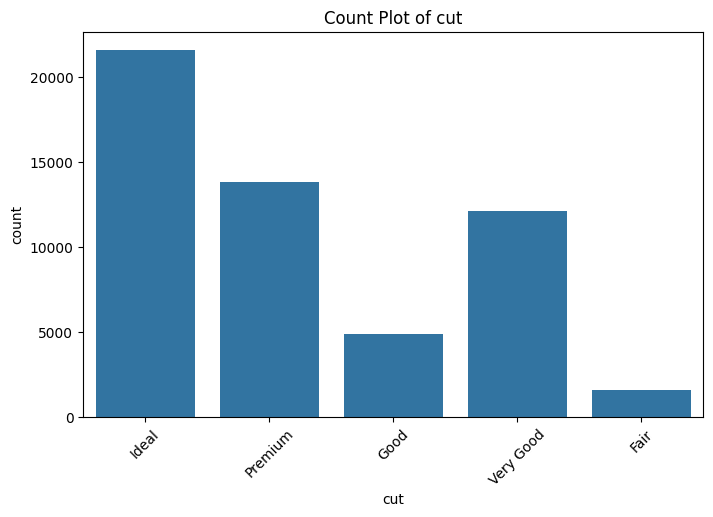

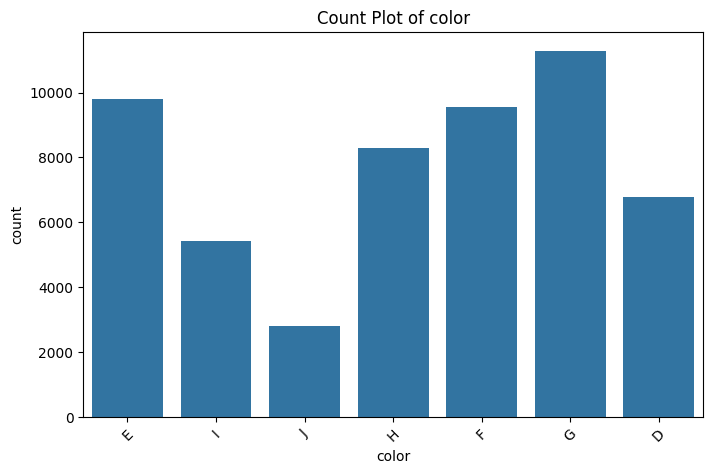

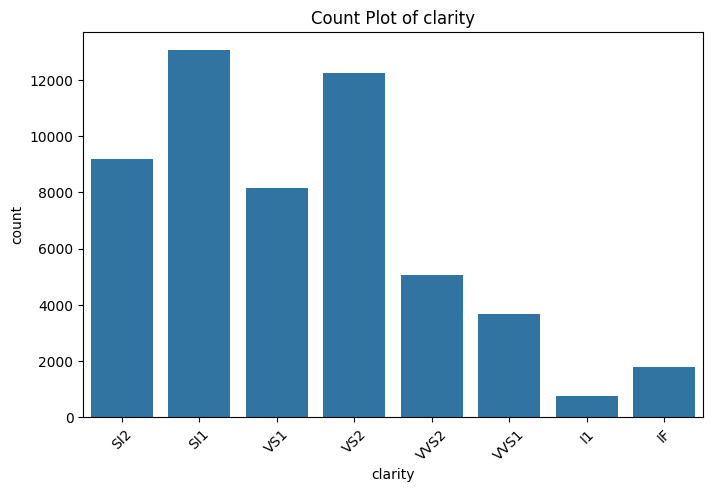

In [ ]:
for col in categorical:
  plt.figure(figsize=(8,5))
  sns.countplot(data=df, x=col)
  plt.title(f'Count Plot of {col}')
  plt.xticks(rotation=45)
  plt.show()

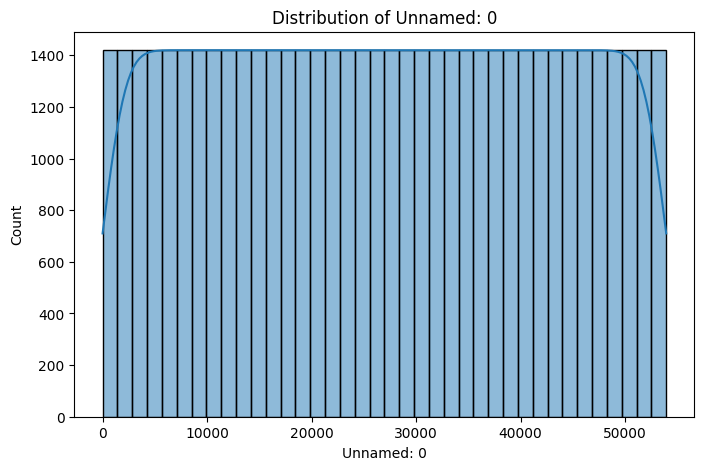

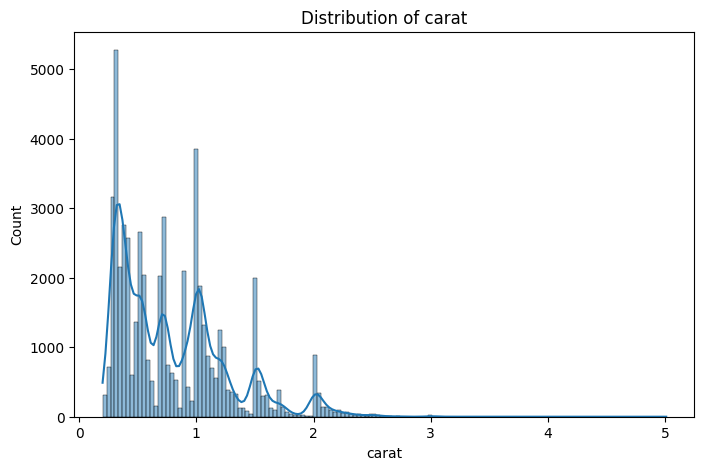

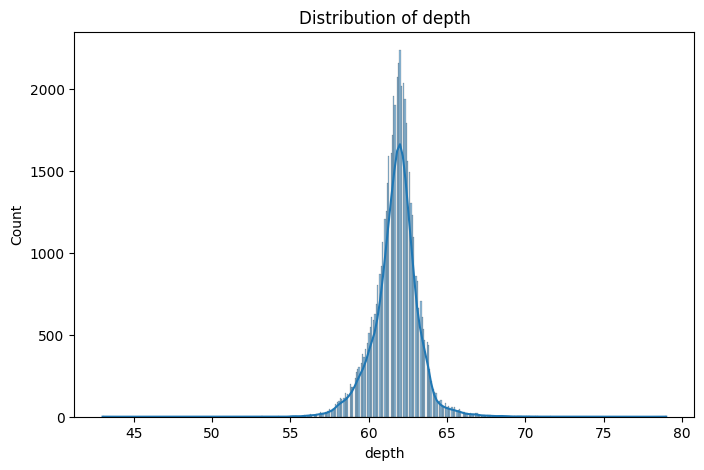

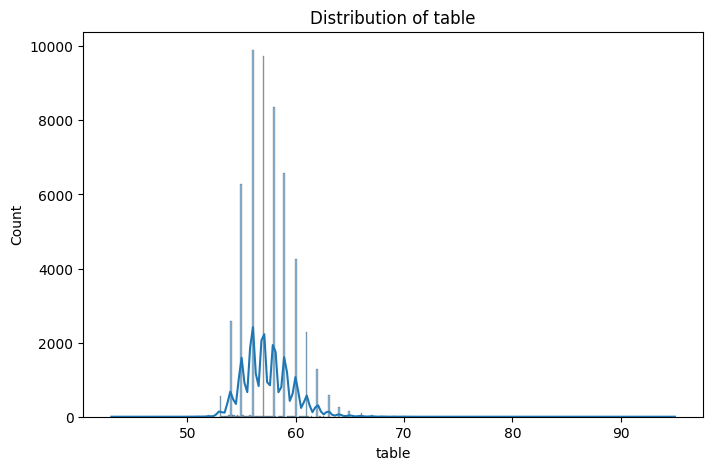

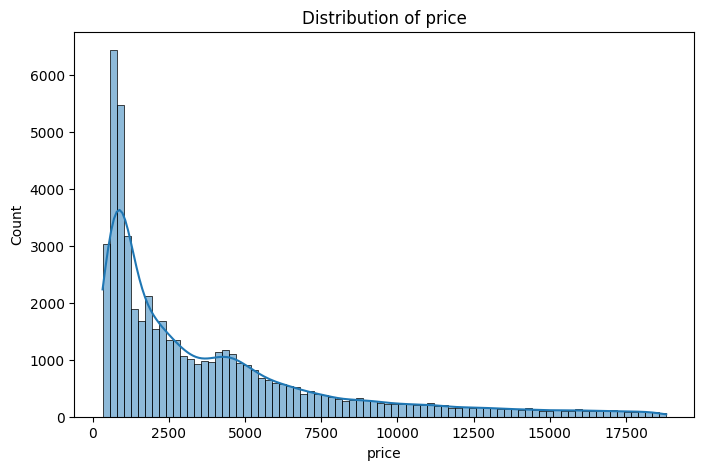

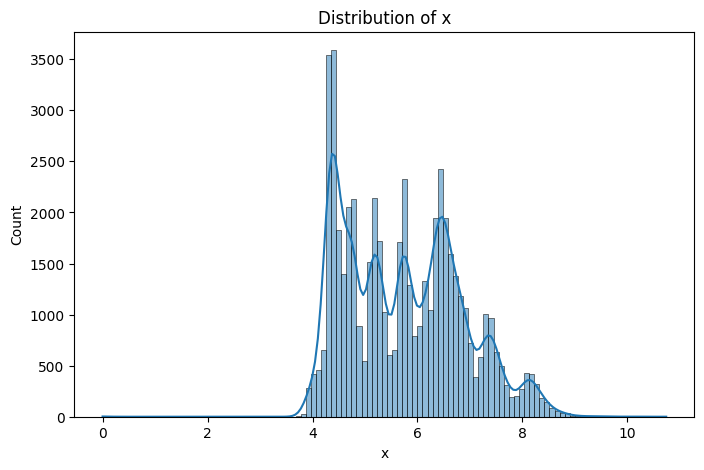

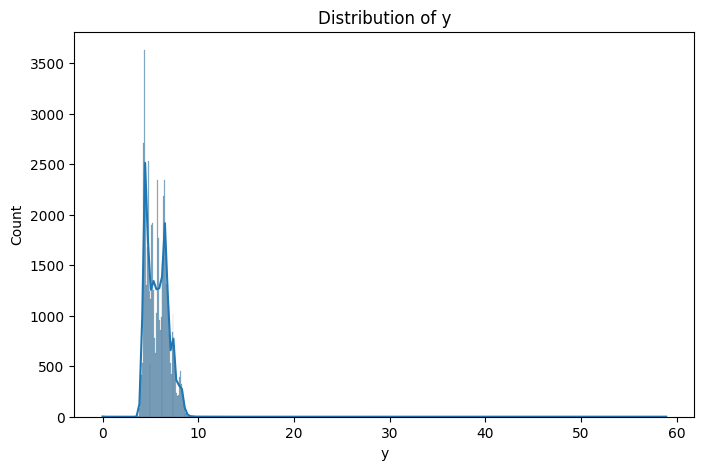

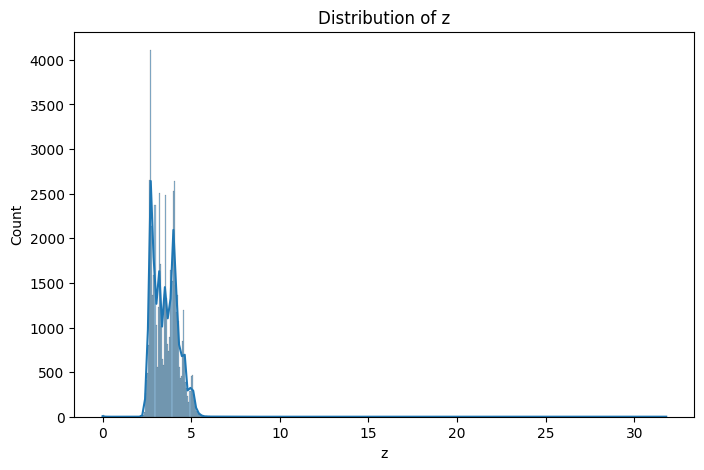

In [ ]:
for col in numerical:
  plt.figure(figsize=(8,5))
  sns.histplot(data=df, x=col,kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()

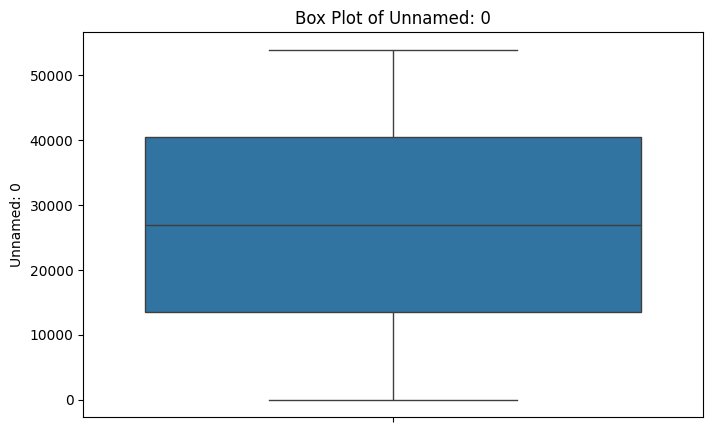

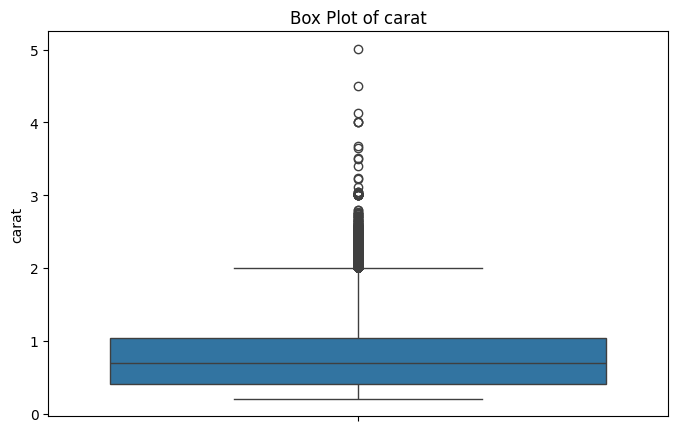

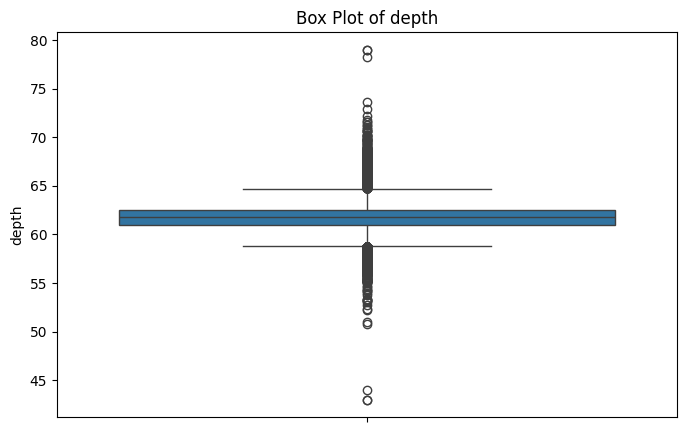

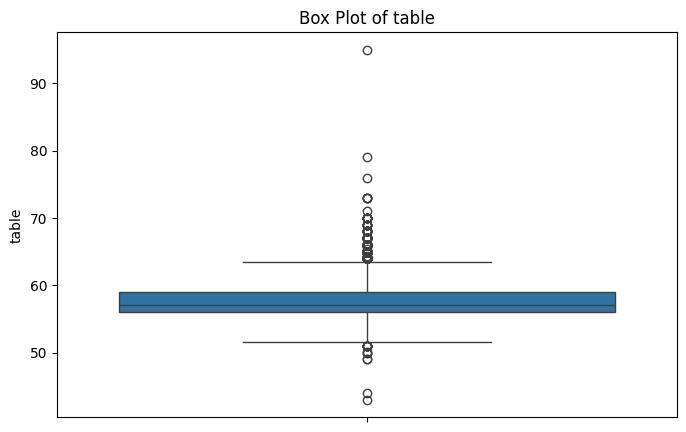

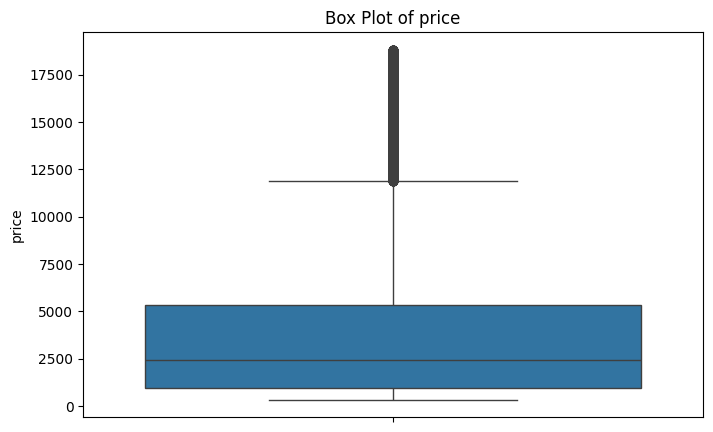

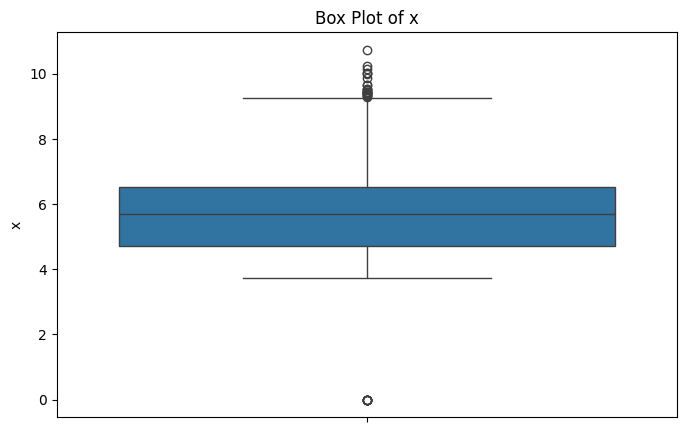

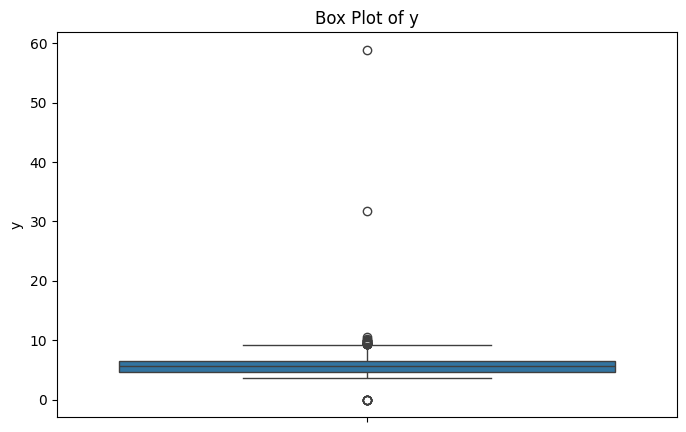

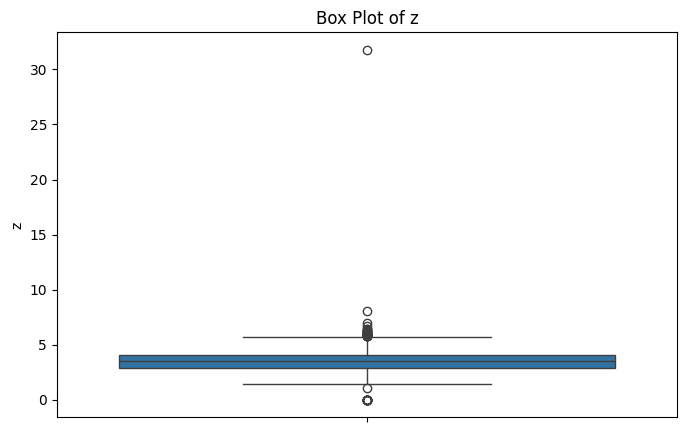

In [ ]:
for col in numerical:
  plt.figure(figsize=(8,5))
  sns.boxplot(data=df, y=col)
  plt.title(f'Box Plot of {col}')
  plt.show()

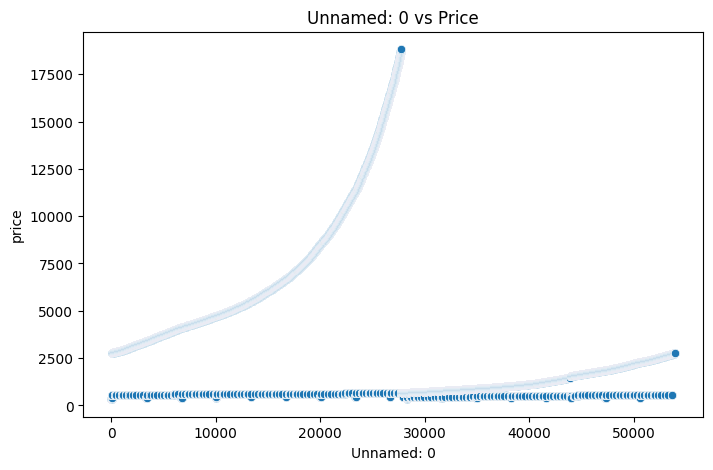

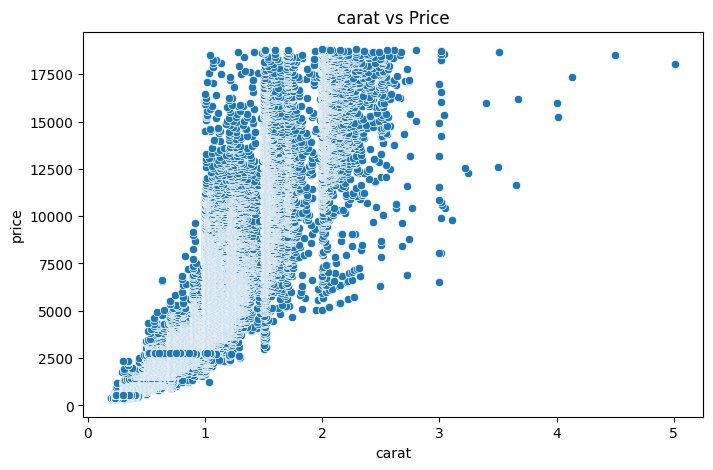

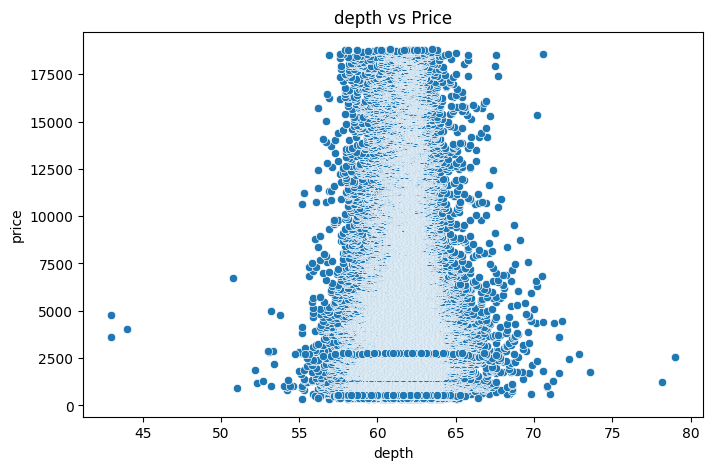

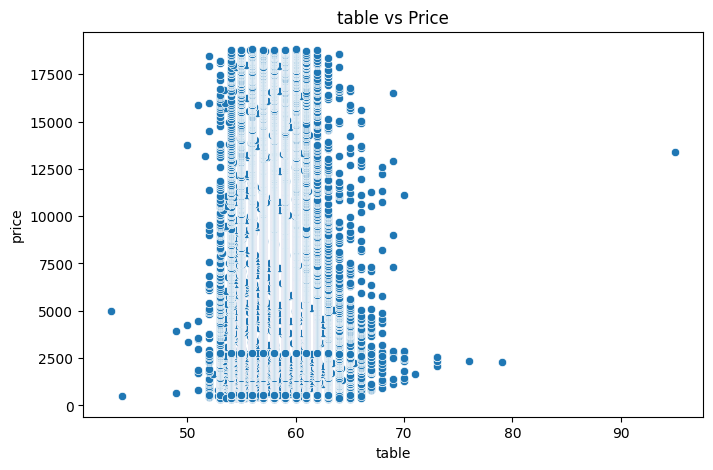

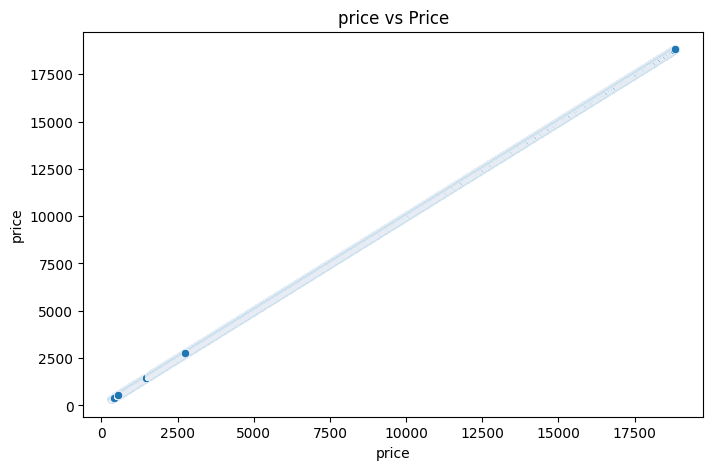

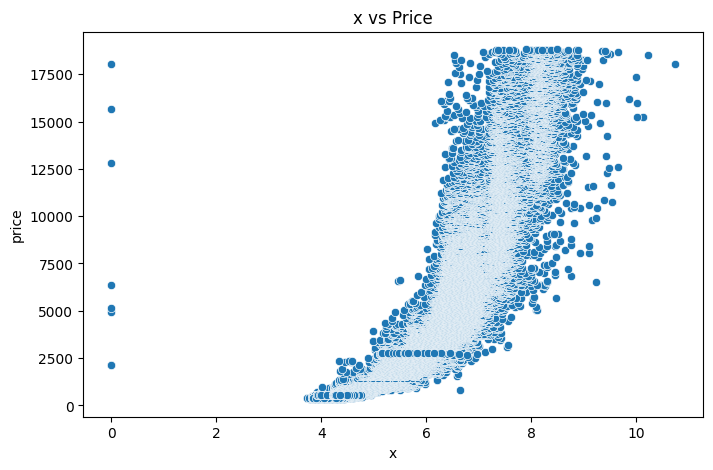

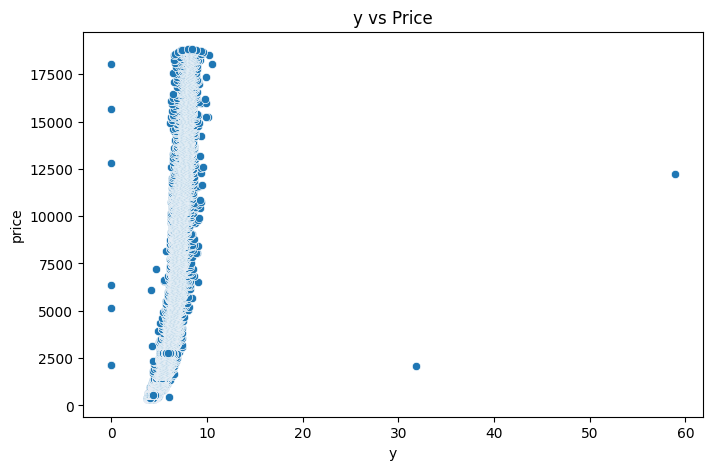

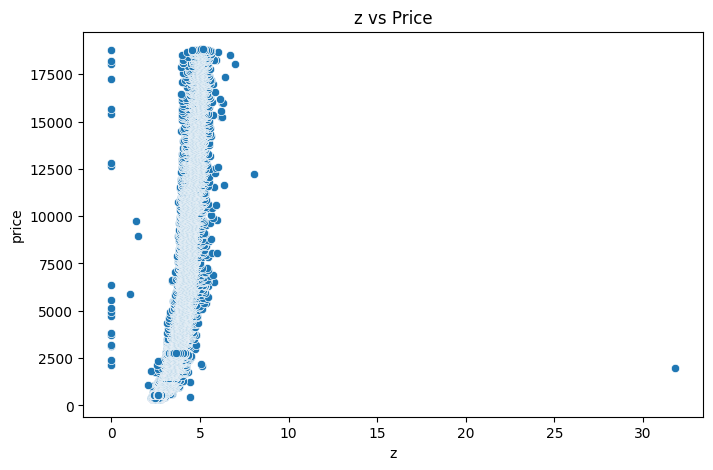

In [ ]:
for col in numerical:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=df, x=col, y='price')
    plt.title(f'{col} vs Price')
    plt.show()

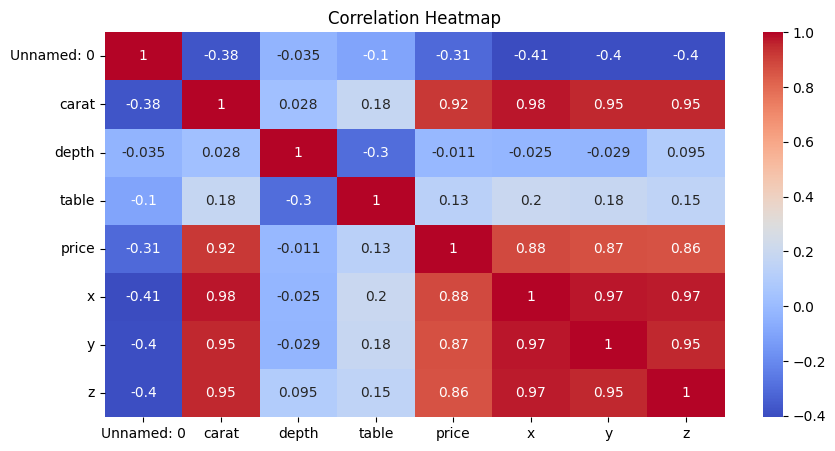

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
for col in numerical:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3-q1
  upper = q3 + 1.5*iqr
  lower = q1 - 1.5*iqr
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(f'{col}: {len(outliers)} outliers : ({len(outliers)/len(df)*100:.2f}%)')

Unnamed: 0: 0 outliers : (0.00%)
carat: 1889 outliers : (3.50%)
depth: 2545 outliers : (4.72%)
table: 605 outliers : (1.12%)
price: 3540 outliers : (6.56%)
x: 32 outliers : (0.06%)
y: 29 outliers : (0.05%)
z: 49 outliers : (0.09%)


##Data Cleaning

In [ ]:
print((df['x'] == 0).sum())
print((df['y'] == 0).sum())
print((df['z'] == 0).sum())

8
7
20


In [ ]:
df.drop(df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)].index, inplace=True)

In [ ]:
(df['y'] == 0).sum()

np.int64(0)

In [ ]:
df['volume'] = df['x']*df['y']*df['z']

In [ ]:
df.drop(['Unnamed: 0','x', 'y', 'z'], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53920 entries, 0 to 53939
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53920 non-null  float64
 1   cut      53920 non-null  object 
 2   color    53920 non-null  object 
 3   clarity  53920 non-null  object 
 4   depth    53920 non-null  float64
 5   table    53920 non-null  float64
 6   price    53920 non-null  int64  
 7   volume   53920 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 3.7+ MB


##Encoding

In [ ]:
df['cut'] = df['cut'].map({'Fair':0, 'Good':1, 'Very Good':2, 'Premium':3, 'Ideal':4})
df['color'] = df['color'].map({'J':0, 'I':1, 'H':2, 'G':3, 'F':4, 'E':5, 'D':6})
df['clarity'] = df['clarity'].map({'I1':0, 'SI2':1, 'SI1':2, 'VS2':3, 'VS1':4, 'VVS2':5, 'VVS1':6, 'IF':7})

In [ ]:
df.head(10)

,carat,cut,color,clarity,depth,table,price,volume
0,0.23,4,5,1,61.5,55.0,326,38.202030
1,0.21,3,5,2,59.8,61.0,326,34.505856
2,0.23,1,5,4,56.9,65.0,327,38.076885
3,0.29,3,1,3,62.4,58.0,334,46.724580
4,0.31,1,0,1,63.3,58.0,335,51.917250
5,0.24,2,0,5,62.8,57.0,336,38.693952
6,0.24,2,1,6,62.3,57.0,336,38.830870
7,0.26,2,2,2,61.9,55.0,337,42.321081
8,0.22,0,5,3,65.1,61.0,337,36.425214
9,0.23,2,2,4,59.4,61.0,338,38.718000


##Train-Test Split

In [ ]:
x = df.drop('price', axis=1)
y = df['price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

##Training Models

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(n_neighbors=9, weights='distance'),
    "SVR": SVR(kernel='rbf',C=100,gamma='auto'),
    "Decision Tree": DecisionTreeRegressor(max_depth=15,min_samples_leaf=10,random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200,max_depth=None,min_samples_leaf=1,random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=200,learning_rate=0.1,random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200,max_depth=5,learning_rate=0.05,random_state=42)
}

In [ ]:
from sklearn.model_selection import cross_val_score
results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    cv = cross_val_score(model,x_train,y_train,cv=5,scoring='r2')
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    results.append({
        'Model': name,
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred),
        'CV Mean R2': cv.mean(),
        'MAE': mean_absolute_error(y_test, y_test_pred),
        'MSE': mean_squared_error(y_test, y_test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
    })
results = pd.DataFrame(results)
results

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.265e+09, tolerance: 5.455e+07
  model = cd_fast.enet_coordinate_descent(


,Model,Train R2,Test R2,CV Mean R2,MAE,MSE,RMSE
0,Linear Regression,0.902658,0.911219,0.876014,839.594545,1.423331e+06,1193.034375
1,Ridge,0.902658,0.911219,0.876578,839.577498,1.423335e+06,1193.036194
2,Lasso,0.902658,0.911208,0.883384,839.230131,1.423516e+06,1193.111868
3,KNN,0.999930,0.970755,0.967651,360.869007,4.688484e+05,684.725059
4,SVR,0.963061,0.963347,0.959794,366.605114,5.876152e+05,766.560633
5,Decision Tree,0.984951,0.975219,0.975322,311.740096,3.972890e+05,630.308615
6,Random Forest,0.997381,0.980869,0.980525,272.245913,3.067006e+05,553.805564
7,AdaBoost,0.921673,0.922256,0.920776,759.520911,1.246395e+06,1116.420633
8,Gradient Boosting,0.985198,0.981485,0.981454,279.350025,2.968375e+05,544.827947


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=25, batch_size=32, validation_split=0.2, callbacks=[early_stop])

Epoch 1/25
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 5165125.5000 - mae: 1177.8400 - val_loss: 2577151.0000 - val_mae: 611.5889
Epoch 2/25
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1160422.1250 - mae: 639.8236 - val_loss: 2436815.2500 - val_mae: 541.7260
Epoch 3/25
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1079439.7500 - mae: 600.7522 - val_loss: 2364086.5000 - val_mae: 507.2506
Epoch 4/25
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1037401.6250 - mae: 575.4385 - val_loss: 2298631.2500 - val_mae: 496.9329
Epoch 5/25
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 991006.8750 - mae: 560.1779 - val_loss: 2298153.0000 - val_mae: 457.5604
Epoch 6/25
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 962762.2500 - mae: 547.5247 - val_loss: 2248330.0000 - val_mae: 466.7780
Epoch 7/25
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 939900.6250 - mae: 540.2469 - val_loss: 2237484.2500 - val_mae: 423.0159
Epoch 8/25
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/s

In [ ]:
y_train_pred = model.predict(x_train).flatten()
y_test_pred = model.predict(x_test).flatten()

results.loc[len(results)] = {
    'Model': 'Neural Network',
    'Train R2': r2_score(y_train, y_train_pred),
    'Test R2': r2_score(y_test, y_test_pred),
    'CV Mean R2': np.nan,
    'MAE': mean_absolute_error(y_test, y_test_pred),
    'MSE': mean_squared_error(y_test, y_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

1348/1348 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
results

,Model,Train R2,Test R2,CV Mean R2,MAE,MSE,RMSE
0,Linear Regression,0.902658,0.911219,0.876014,839.594545,1.423331e+06,1193.034375
1,Ridge,0.902658,0.911219,0.876578,839.577498,1.423335e+06,1193.036194
2,Lasso,0.902658,0.911208,0.883384,839.230131,1.423516e+06,1193.111868
3,KNN,0.999930,0.970755,0.967651,360.869007,4.688484e+05,684.725059
4,SVR,0.963061,0.963347,0.959794,366.605114,5.876152e+05,766.560633
5,Decision Tree,0.984951,0.975219,0.975322,311.740096,3.972890e+05,630.308615
6,Random Forest,0.997381,0.980869,0.980525,272.245913,3.067006e+05,553.805564
7,AdaBoost,0.921673,0.922256,0.920776,759.520911,1.246395e+06,1116.420633
8,Gradient Boosting,0.985198,0.981485,0.981454,279.350025,2.968375e+05,544.827947
9,Neural Network,0.957341,0.964659,NaN,381.725464,5.665790e+05,752.714421


##The Best Model

In [ ]:
best_model = GradientBoostingRegressor(n_estimators=200,max_depth=5,learning_rate=0.05,random_state=42)
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.9814846306306937
279.3500249081245


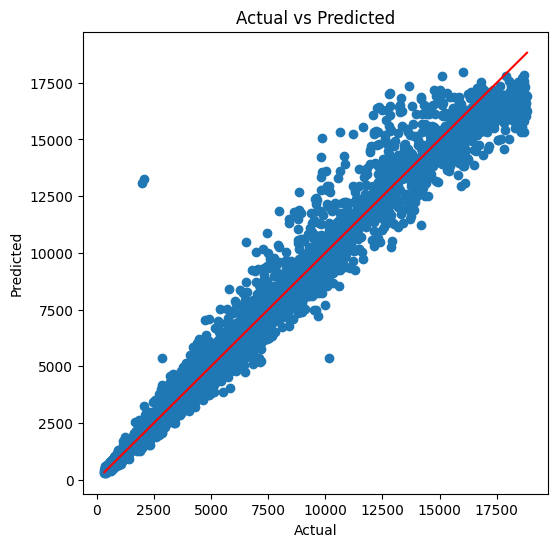

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

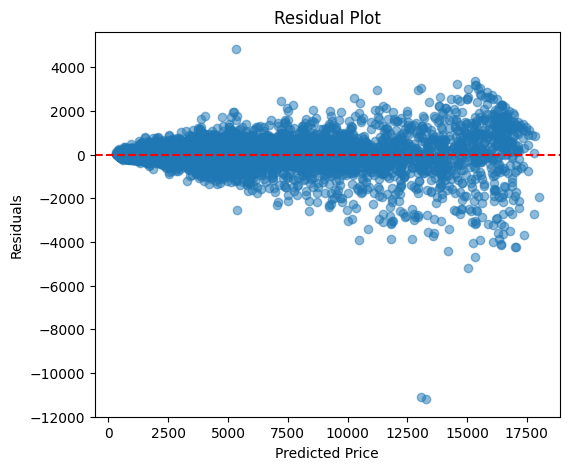

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()